In [1]:
# Get ELENA
!git clone https://github.com/michelelucente/ELENA.git
%cd ELENA

# Install Python deps for notebooks + examples
# (names follow ELENA’s README; CosmoTransitions is on PyPI)
%pip install -q numpy scipy matplotlib cosmoTransitions NatPy la-forge


Cloning into 'ELENA'...
remote: Enumerating objects: 624, done.
remote: Counting objects: 100% (231/231), done.
remote: Compressing objects: 100% (137/137), done.
remote: Total 624 (delta 168), reused 142 (delta 89), pack-reused 393 (from 1)
Receiving objects: 100% (624/624), 30.17 MiB | 19.40 MiB/s, done.
Resolving deltas: 100% (426/426), done.
/content/ELENA
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.2/62.2 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 3.1 MB/s eta 0:00:00


In [2]:
%%writefile custom_model.py
"""
custom_model.py

Paper-consistent Abelian-Higgs finite-temperature model
using a CosmoTransitions-compatible framework.

This version is designed to match the literature setup much more closely:

  V_eff(phi, T; mu) =
      V_tree(phi; mu)
    + V_CW(phi; mu)
    + V_T(phi, T; mu)
    + V_Daisy(phi, T; mu)

with

  V_tree(phi) = - m^2(mu) phi^2 / 2 + lambda(mu) phi^4 / 4

field-dependent masses:
  m_h^2(phi) = 3 lambda(phi) phi^2 - m^2
  m_g^2(phi) = lambda(phi) phi^2 - m^2
  m_A^2(phi) = g^2 phi^2

thermal masses from the paper:
  Pi_{h,g} = lambda T^2 / 3 + g^2 T^2 / 4
  Pi_{A_L} = g^2 T^2 / 3

RGEs from the paper:
  beta_{g^2} = g^4 / (24 pi^2)
  beta_lambda = (10 lambda^2 - 6 lambda g^2 + 3 g^4) / (8 pi^2)
  beta_{m^2} = m^2 (4 lambda - 3 g^2) / (8 pi^2)

Default scale choice:
  mu(T) = pi T    for T > 0
  mu(0) = mu0     fallback

Notes
-----
1. This file keeps the GenericCTModel wrapper so your existing workflow
   remains familiar.
2. The CW piece is implemented directly in MS-bar/Landau-gauge style.
3. Daisy resummation uses the Arnold-Espinosa prescription.
4. For numerical stability, logarithms use abs(m^2) inside logs and small
   regulators near zero. This is a practical real-valued implementation.
"""

import numpy as np
from scipy.integrate import solve_ivp

from cosmoTransitions import generic_potential, helper_functions


# -------------------------
# Small stability utilities
# -------------------------
def _as_float_array(x):
    return np.asanyarray(x, dtype=float)

def _as_float_scalar(x):
    return float(np.asanyarray(x, dtype=float))

def _clip_m2_nonneg(m2):
    return np.maximum(np.asanyarray(m2, dtype=float), 0.0)

def _finite_or_big(y, big=1e300):
    """
    Replace non-finite values by a huge barrier value.
    Works on scalars and arrays.
    """
    y = np.asanyarray(y)
    if np.isscalar(y) or y.shape == ():
        return y if np.isfinite(y) else big
    out = y.copy()
    mask = ~np.isfinite(out)
    if np.any(mask):
        out[mask] = big
    return out

def _adaptive_T_step(T, eps_abs=1e-6, eps_rel=1e-3, Tmin_step=1e-6):
    T = float(T)
    return max(float(eps_abs), float(eps_rel) * abs(T), float(Tmin_step))

def _safe_log_argument(x, floor=1e-300):
    """
    Stable positive argument for logarithms.
    """
    x = np.asanyarray(x, dtype=float)
    return np.maximum(np.abs(x), floor)

def _safe_mass4_log_term(m2, mu2, const):
    """
    Stable real-valued implementation of m^4 [ln(m^2/mu^2) - const].
    Uses |m^2| inside the log, which is a common practical real-valued choice
    in effective-potential numerics.
    """
    m2 = np.asanyarray(m2, dtype=float)
    mu2 = float(mu2)
    return (m2 ** 2) * (np.log(_safe_log_argument(m2) / mu2) - const)


# --------------------------------
# Generic CT-style engine
# --------------------------------
class GenericCTModel(generic_potential.generic_potential):
    """
    Generic CosmoTransitions-compatible model.

    You supply:
      - V0_fun(X, T)               : tree-level piece
      - boson_fun(X, T)            : (M2, dof, c)
      - fermion_fun(X)             : (M2, dof)
      - Vct_fun(X, T)              : optional counterterm-like piece
      - Vcw_fun(X, T)              : optional custom zero-T loop piece
      - use_ct_cw                  : whether to use CT's built-in V1 or Vcw_fun
      - daisyType:
          0 -> no daisy
          1 -> Parwani
          2 -> Arnold-Espinosa
    """

    def init(
        self,
        Ndim,
        V0_fun,
        boson_fun,
        fermion_fun=None,
        Vct_fun=None,
        Vcw_fun=None,
        use_ct_cw=False,
        xstep=1e-3,
        Tstep_abs=1e-4,
        Tstep_rel=1e-3,
        Tmin_step=1e-6,
        daisyType=2,
        deriv_order=2,
    ):
        self.Ndim = int(Ndim)
        if V0_fun is None or boson_fun is None:
            raise ValueError("GenericCTModel requires at least V0_fun and boson_fun.")

        self._V0_fun = V0_fun
        self._boson_fun = boson_fun
        self._fermion_fun = fermion_fun if fermion_fun is not None else (lambda X: (0.0, 0.0))
        self._Vct_fun = Vct_fun if Vct_fun is not None else (lambda X, T: 0.0)
        self._Vcw_fun = Vcw_fun if Vcw_fun is not None else (lambda X, T: 0.0)

        self.use_ct_cw = bool(use_ct_cw)

        self.x_eps = float(xstep)
        self.T_eps_abs = float(Tstep_abs)
        self.T_eps_rel = float(Tstep_rel)
        self.Tmin_step = float(Tmin_step)

        self.daisyResum = int(daisyType)
        self.deriv_order = int(deriv_order)

    # CT-required
    def V0(self, X):
        # Fallback required by CT interface, but our actual Vtot below calls V0_fun(X, T)
        return self._V0_fun(_as_float_array(X), 0.0)

    def Vct(self, X):
        return self._Vct_fun(_as_float_array(X), 0.0)

    def boson_massSq(self, X, T):
        return self._boson_fun(_as_float_array(X), _as_float_scalar(T))

    def fermion_massSq(self, X):
        return self._fermion_fun(_as_float_array(X))

    def Vtot(self, X, T, include_radiation=True):
        X = _as_float_array(X)
        T = _as_float_array(T)

        fermions = self.fermion_massSq(X)
        bosons0 = self.boson_massSq(X, 0.0 * T)

        y = self._V0_fun(X, T)

        # Zero-temperature loop piece
        if self.use_ct_cw:
            y = y + self.V1(bosons0, fermions) + self._Vct_fun(X, T)
        else:
            y = y + self._Vcw_fun(X, T) + self._Vct_fun(X, T)

        # Thermal + daisy
        if self.daisyResum == 0:
            y = y + self.V1T(bosons0, fermions, T, include_radiation)

        elif self.daisyResum == 1:
            bosonsT = self.boson_massSq(X, T)
            y = y + self.V1T(bosonsT, fermions, T, include_radiation)

        elif self.daisyResum == 2:
            # Arnold-Espinosa: V1T(bosons0) + ring from bosonsT - bosons0
            bosonsT = self.boson_massSq(X, T)
            m20, nb, _ = bosons0
            m2T, _, _ = bosonsT

            m20c = _clip_m2_nonneg(m20)
            m2Tc = _clip_m2_nonneg(m2T)

            Vring = -(T / (12.0 * np.pi)) * np.sum(
                nb * (np.power(m2Tc, 1.5) - np.power(m20c, 1.5)),
                axis=-1
            )
            y = y + self.V1T(bosons0, fermions, T, include_radiation) + Vring

        else:
            raise ValueError("daisyType must be 0, 1, or 2.")

        return _finite_or_big(y)

    def DVtot(self, X, T):
        X = _as_float_array(X)
        return self.Vtot(X, T, include_radiation=False) - self.Vtot(X * 0.0, T, include_radiation=False)

    def gradV(self, X, T):
        try:
            f = self._gradV
        except AttributeError:
            self._gradV = helper_functions.gradientFunction(
                self.Vtot, self.x_eps, self.Ndim, self.deriv_order
            )
            f = self._gradV

        T = np.asanyarray(T)[..., np.newaxis, np.newaxis]
        return f(X, T, False)

    # -------------------------------
    # Temperature derivatives (stable)
    # -------------------------------
    def dVdT(self, X, T, include_radiation=True, include_SM=False, units="GeV"):
        X = _as_float_array(X)
        T = float(T)

        h = _adaptive_T_step(
            T,
            eps_abs=self.T_eps_abs,
            eps_rel=self.T_eps_rel,
            Tmin_step=self.Tmin_step,
        )

        if T <= h:
            V0 = self.Vtot(X, 0.0, include_radiation=include_radiation)
            V1 = self.Vtot(X, h, include_radiation=include_radiation)
            d = (V1 - V0) / h
        else:
            Vm = self.Vtot(X, T - h, include_radiation=include_radiation)
            Vp = self.Vtot(X, T + h, include_radiation=include_radiation)
            d = (Vp - Vm) / (2.0 * h)

        # No SM subtraction in this minimal paper model
        return d

    def d2VdT2(self, X, T, include_radiation=True, include_SM=False, units="GeV"):
        X = _as_float_array(X)
        T = float(T)

        h = _adaptive_T_step(
            T,
            eps_abs=self.T_eps_abs,
            eps_rel=self.T_eps_rel,
            Tmin_step=self.Tmin_step,
        )

        if T <= 2.0 * h:
            V0 = self.Vtot(X, 0.0, include_radiation=include_radiation)
            Vh = self.Vtot(X, h, include_radiation=include_radiation)
            V2h = self.Vtot(X, 2.0 * h, include_radiation=include_radiation)
            val = (V2h - 2.0 * Vh + V0) / (h * h)
        else:
            Vm = self.Vtot(X, T - h, include_radiation=include_radiation)
            Vc = self.Vtot(X, T, include_radiation=include_radiation)
            Vp = self.Vtot(X, T + h, include_radiation=include_radiation)
            val = (Vp - 2.0 * Vc + Vm) / (h * h)

        return val


# ---------------------------------------------------------
# Paper-consistent Abelian-Higgs 4D HT + Daisy model
# ---------------------------------------------------------
class AbelianHiggsMSbarPaper(GenericCTModel):
    """
    Abelian-Higgs model matched to the paper's 4D scheme.

    Parameters are defined at a reference scale mu0:
      g2(mu0), lambda(mu0), m2(mu0)

    Tree-level potential:
      V_tree = -m2(mu) phi^2 / 2 + lambda(mu) phi^4 / 4

    Field-dependent masses:
      m_h^2 = 3 lambda(mu) phi^2 - m2(mu)
      m_g^2 =   lambda(mu) phi^2 - m2(mu)
      m_A^2 = g2(mu) phi^2

    Thermal masses:
      Pi_{h,g} = lambda(mu) T^2 / 3 + g2(mu) T^2 / 4
      Pi_{A_L} = g2(mu) T^2 / 3

    Default renormalization scale:
      mu(T) = pi T  for T > 0
      mu(0) = mu0
    """

    def init(
        self,
        g2_0=0.36,          # g(mu0)^2
        lambda_0=0.0,       # lambda(mu0)
        m2_0=0.0,           # m^2(mu0), note paper tree uses -m^2 phi^2 / 2
        mu0=1.0,            # reference scale
        use_running=True,
        use_paper_mu=True,  # mu(T) = pi T for T>0, else mu0
        xstep=5e-5,
        Tstep_abs=1e-4,
        Tstep_rel=1e-3,
        Tmin_step=1e-6,
        deriv_order=2,
        daisyType=2,        # Arnold-Espinosa by default
    ):
        self.g2_0 = float(g2_0)
        self.lambda_0 = float(lambda_0)
        self.m2_0 = float(m2_0)
        self.mu0 = float(mu0)

        self.use_running = bool(use_running)
        self.use_paper_mu = bool(use_paper_mu)

        # cache for repeated running evaluations
        self._rge_cache = {}

        # -------------------------
        # scale choice
        # -------------------------
        def mu_eff(T):
            T = float(np.asanyarray(T, dtype=float))
            if self.use_paper_mu and T > 0.0:
                return max(np.pi * T, 1e-12)
            return max(self.mu0, 1e-12)

        self.mu_eff = mu_eff

        # -------------------------
        # one-loop RGEs from paper
        # -------------------------
        def rge_rhs(t, y):
            # t = ln(mu / mu0)
            g2, lam, m2 = y

            beta_g2 = (g2 ** 2) / (24.0 * np.pi ** 2)
            beta_lam = (10.0 * lam ** 2 - 6.0 * lam * g2 + 3.0 * g2 ** 2) / (8.0 * np.pi ** 2)
            beta_m2 = m2 * (4.0 * lam - 3.0 * g2) / (8.0 * np.pi ** 2)

            return [beta_g2, beta_lam, beta_m2]

        self._rge_rhs = rge_rhs

        def run_params(mu):
            """
            Return g2(mu), lambda(mu), m2(mu).
            """
            mu = max(float(mu), 1e-12)

            if not self.use_running:
                return self.g2_0, self.lambda_0, self.m2_0

            key = round(mu, 12)
            if key in self._rge_cache:
                return self._rge_cache[key]

            if abs(mu - self.mu0) / max(self.mu0, 1e-12) < 1e-14:
                out = (self.g2_0, self.lambda_0, self.m2_0)
                self._rge_cache[key] = out
                return out

            t1 = np.log(mu / self.mu0)
            sol = solve_ivp(
                self._rge_rhs,
                (0.0, t1),
                [self.g2_0, self.lambda_0, self.m2_0],
                method="RK45",
                rtol=1e-8,
                atol=1e-10,
                dense_output=False,
                max_step=max(abs(t1) / 100.0, 1e-3),
            )
            if not sol.success:
                raise RuntimeError(f"RGE evolution failed: {sol.message}")

            g2_mu, lam_mu, m2_mu = [float(v) for v in sol.y[:, -1]]
            out = (g2_mu, lam_mu, m2_mu)
            self._rge_cache[key] = out
            return out

        self.run_params = run_params

        # -------------------------
        # masses at given (phi, T)
        # -------------------------
        def masses_zeroT(phi, T):
            mu = self.mu_eff(T)
            g2, lam, m2 = self.run_params(mu)

            mH2 = 3.0 * lam * phi ** 2 - m2
            mG2 = 1.0 * lam * phi ** 2 - m2
            mA2 = g2 * phi ** 2
            return mH2, mG2, mA2, g2, lam, m2, mu

        self.masses_zeroT = masses_zeroT

        # -------------------------
        # tree-level piece
        # -------------------------
        def V0_fun(X, T):
            X = _as_float_array(X)
            phi = X[..., 0]

            _, _, _, _, lam, m2, _ = self.masses_zeroT(phi, T)
            return -0.5 * m2 * phi ** 2 + 0.25 * lam * phi ** 4

        # -------------------------
        # MS-bar Coleman-Weinberg
        # -------------------------
        def Vcw_msbar(X, T):
            X = _as_float_array(X)
            phi = X[..., 0]

            mH2, mG2, mA2, _, _, _, mu = self.masses_zeroT(phi, T)
            mu2 = mu ** 2

            # Paper-like Landau-gauge CW:
            #   m_h^4 [ln(m_h^2/mu^2) - 3/2]
            # + m_g^4 [ln(m_g^2/mu^2) - 3/2]
            # + 3 m_A^4 [ln(m_A^2/mu^2) - 5/6]
            termH = _safe_mass4_log_term(mH2, mu2, 1.5)
            termG = _safe_mass4_log_term(mG2, mu2, 1.5)
            termA = 3.0 * _safe_mass4_log_term(mA2, mu2, 5.0 / 6.0)

            return (termH + termG + termA) / (64.0 * np.pi ** 2)

        # -------------------------
        # bosonic spectrum
        # -------------------------
        def boson_fun(X, T):
            """
            Returns [H, G, A_T, A_L] with dof [1,1,2,1].

            For T > 0:
              Pi_{H,G} = lambda T^2 / 3 + g^2 T^2 / 4
              Pi_{A_L} = g^2 T^2 / 3
              A_T is not Debye-resummed
            """
            X = _as_float_array(X)
            phi = X[..., 0]
            T = float(np.asanyarray(T, dtype=float))

            mH2, mG2, mA2, g2, lam, _, _ = self.masses_zeroT(phi, T)

            if T > 0.0:
                PiS = (lam / 3.0 + g2 / 4.0) * T ** 2
                PiL = (g2 / 3.0) * T ** 2

                mH2_eff = mH2 + PiS
                mG2_eff = mG2 + PiS
                mAT2_eff = mA2
                mAL2_eff = mA2 + PiL
            else:
                mH2_eff = mH2
                mG2_eff = mG2
                mAT2_eff = mA2
                mAL2_eff = mA2

            M2 = np.stack([mH2_eff, mG2_eff, mAT2_eff, mAL2_eff], axis=-1)
            dof = np.array([1.0, 1.0, 2.0, 1.0])
            c = np.array([1.5, 1.5, 5.0 / 6.0, 5.0 / 6.0])
            return M2, dof, c

        def fermion_fun(X):
            return 0.0, 0.0

        super().init(
            Ndim=1,
            V0_fun=V0_fun,
            boson_fun=boson_fun,
            fermion_fun=fermion_fun,
            Vct_fun=None,
            Vcw_fun=Vcw_msbar,
            use_ct_cw=False,
            xstep=xstep,
            Tstep_abs=Tstep_abs,
            Tstep_rel=Tstep_rel,
            Tmin_step=Tmin_step,
            daisyType=daisyType,
            deriv_order=deriv_order,
        )

    def approxZeroTMin(self):
        """
        Approximate zero-temperature minimum from tree level:
          phi^2 = m^2 / lambda  when lambda > 0 and m^2 > 0.
        """
        g2, lam, m2 = self.run_params(self.mu0)

        if lam > 0.0 and m2 > 0.0:
            vev = np.sqrt(m2 / lam)
            return [np.array([vev], dtype=float)]

        return [np.array([0.0], dtype=float)]


# Compatibility alias
DarkPhotonMSbarRG = AbelianHiggsMSbarPaper

Writing custom_model.py


/usr/local/lib/python3.12/dist-packages/cosmoTransitions/finiteT.py:88: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  integrate.quad(f1, 0, abs(theta)**.5)[0]


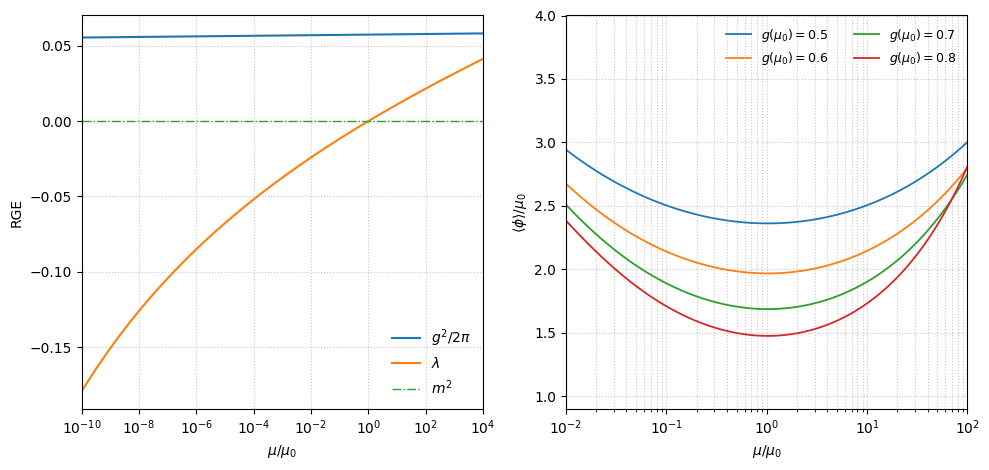

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

from custom_model import AbelianHiggsMSbarPaper

# ============================================================
# Helpers
# ============================================================
def safe_log_arg(x, floor=1e-300):
    return np.maximum(np.abs(x), floor)

def safe_mass4_log_term(m2, mu2, const):
    return (m2**2) * (np.log(safe_log_arg(m2) / mu2) - const)

def Veff_zeroT(phi, model, mu):
    """
    Zero-temperature RG-improved 1-loop effective potential at fixed renormalisation scale mu.
    """
    g2, lam, m2 = model.run_params(mu)
    mu2 = mu**2

    # Tree
    Vtree = -0.5 * m2 * phi**2 + 0.25 * lam * phi**4

    # Field-dependent masses
    mH2 = 3.0 * lam * phi**2 - m2
    mG2 = 1.0 * lam * phi**2 - m2
    mA2 = g2 * phi**2

    # Coleman-Weinberg
    termH = safe_mass4_log_term(mH2, mu2, 1.5)
    termG = safe_mass4_log_term(mG2, mu2, 1.5)
    termA = 3.0 * safe_mass4_log_term(mA2, mu2, 5.0 / 6.0)
    VCW = (termH + termG + termA) / (64.0 * np.pi**2)

    return Vtree + VCW

def find_vev(model, mu, phi_max=8.0, ngrid=4000):
    """
    Find the nontrivial minimum of Veff(phi; mu) at T=0.
    Returns vev in units of mu0.
    """
    # first do a coarse scan to bracket the minimum
    phis = np.linspace(1e-6, phi_max, ngrid)
    vals = np.array([Veff_zeroT(phi, model, mu) for phi in phis])

    i_min = np.argmin(vals)
    phi_guess = phis[i_min]

    # If minimum sits at edge, enlarge search window
    if i_min == 0 or i_min == len(phis) - 1:
        # try a larger range
        phi_max2 = 20.0
        phis = np.linspace(1e-6, phi_max2, ngrid)
        vals = np.array([Veff_zeroT(phi, model, mu) for phi in phis])
        i_min = np.argmin(vals)
        phi_guess = phis[i_min]

    # bracket around the coarse minimum
    left = phis[max(i_min - 1, 0)]
    right = phis[min(i_min + 1, len(phis) - 1)]

    # if still too tight, widen slightly
    if right - left < 1e-6:
        left = max(phi_guess * 0.8, 1e-8)
        right = phi_guess * 1.2 + 1e-8

    res = minimize_scalar(
        lambda x: Veff_zeroT(x, model, mu),
        bounds=(left, right),
        method="bounded"
    )
    return res.x

# ============================================================
# Figure setup
# ============================================================
mu0 = 1.0

fig, axes = plt.subplots(1, 2, figsize=(10, 4.8))

# ============================================================
# LEFT PANEL: RGE running for g(mu0)=0.6
# ============================================================
g0 = 0.6
model_left = AbelianHiggsMSbarPaper(
    g2_0=g0**2,
    lambda_0=0.0,
    m2_0=0.0,
    mu0=mu0,
    use_running=True,
    use_paper_mu=False,   # we want direct control of mu here
)

mu_vals_left = np.logspace(-10, 4, 500)
g2_over_2pi = []
lam_vals = []
m2_vals = []

for mu in mu_vals_left:
    g2, lam, m2 = model_left.run_params(mu)
    g2_over_2pi.append(g2 / (2.0 * np.pi))
    lam_vals.append(lam)
    m2_vals.append(m2)

ax = axes[0]
ax.plot(mu_vals_left / mu0, g2_over_2pi, label=r"$g^2/2\pi$", lw=1.5)
ax.plot(mu_vals_left / mu0, lam_vals, label=r"$\lambda$", lw=1.5)
ax.plot(mu_vals_left / mu0, m2_vals, label=r"$m^2$", lw=1.0, ls="-.")
ax.set_xscale("log")
ax.set_xlabel(r"$\mu/\mu_0$")
ax.set_ylabel("RGE")
ax.set_xlim(mu_vals_left[0] / mu0, mu_vals_left[-1] / mu0)
ax.grid(True, which="both", ls=":", alpha=0.7)
ax.legend(frameon=False, fontsize=10)

# ============================================================
# RIGHT PANEL: vev/mu0 vs mu/mu0 for several g(mu0)
# ============================================================
g_list = [0.5, 0.6, 0.7, 0.8]
mu_vals_right = np.logspace(-2, 2, 120)

ax = axes[1]

for g in g_list:
    model = AbelianHiggsMSbarPaper(
        g2_0=g**2,
        lambda_0=0.0,
        m2_0=0.0,
        mu0=mu0,
        use_running=True,
        use_paper_mu=False,
    )

    vevs = []
    for mu in mu_vals_right:
        vev = find_vev(model, mu, phi_max=8.0, ngrid=3000)
        vevs.append(vev / mu0)

    ax.plot(mu_vals_right / mu0, vevs, lw=1.3, label=rf"$g(\mu_0)={g}$")

ax.set_xscale("log")
ax.set_xlabel(r"$\mu/\mu_0$")
ax.set_ylabel(r"$\langle \phi \rangle/\mu_0$")
ax.set_xlim(mu_vals_right[0] / mu0, mu_vals_right[-1] / mu0)
ax.set_ylim(0.9, 4.0)
ax.grid(True, which="both", ls=":", alpha=0.7)
ax.legend(frameon=False, fontsize=9, ncol=2)

plt.tight_layout()
plt.show()

In [2]:
content = """V[phi_, T_] := (msq*ϕ^2)/2 + (λ*ϕ^4)/4 - (g1^2*Yϕ^2*ϕ^2)^(3/2)/(6*Pi) + (g1^2*Yϕ^2*Sqrt[g1^2*Yϕ^2*ϕ^2]*Sqrt[msq + λ*ϕ^2])/(16*Pi^2) + (3*λ*(msq + λ*ϕ^2))/(64*Pi^2) - (msq + λ*ϕ^2)^(3/2)/(12*Pi) + (g1^2*Yϕ^2*Sqrt[g1^2*Yϕ^2*ϕ^2]*Sqrt[msq + 3*λ*ϕ^2])/(16*Pi^2) + (λ*Sqrt[msq + λ*ϕ^2]*Sqrt[msq + 3*λ*ϕ^2])/(32*Pi^2) + (3*λ*(msq + 3*λ*ϕ^2))/(64*Pi^2) - (msq + 3*λ*ϕ^2)^(3/2)/(12*Pi) - (3*λ^2*ϕ^2*(1/2 + Log[μ3US/(3*Sqrt[msq + 3*λ*ϕ^2])]))/(16*Pi^2) + ((g1^4*Yϕ^4*ϕ^4)/(8*Pi^2) - (g1^2*Yϕ^2*ϕ^2*(-msq + 2*g1^2*Yϕ^2*ϕ^2 - 3*λ*ϕ^2))/(16*Pi^2) + (g1^2*Yϕ^2*ϕ^2*Sqrt[g1^2*Yϕ^2*ϕ^2]*Sqrt[msq + 3*λ*ϕ^2])/(8*Pi^2) - ((msq + 3*λ*ϕ^2)^2*(1/2 + Log[μ3US/Sqrt[msq + 3*λ*ϕ^2]]))/(16*Pi^2) + ((-msq + g1^2*Yϕ^2*ϕ^2 - 3*λ*ϕ^2)^2*(1/2 + Log[μ3US/(Sqrt[g1^2*Yϕ^2*ϕ^2] + Sqrt[msq + 3*λ*ϕ^2])]))/(8*Pi^2) - ((7*g1^4*Yϕ^4*ϕ^4 + (-msq + g1^2*Yϕ^2*ϕ^2 - 3*λ*ϕ^2)^2 - 2*g1^2*Yϕ^2*ϕ^2*(msq + 3*λ*ϕ^2))*(1/2 + Log[μ3US/(2*Sqrt[g1^2*Yϕ^2*ϕ^2] + Sqrt[msq + 3*λ*ϕ^2])]))/(16*Pi^2))/(4*ϕ^2) + (-1/16*(Sqrt[g1^2*Yϕ^2*ϕ^2]*(g1^2*Yϕ^2*ϕ^2 - 2*λ*ϕ^2)*Sqrt[msq + λ*ϕ^2])/Pi^2 + (Sqrt[msq + 3*λ*ϕ^2]*((g1^2*Yϕ^2*ϕ^2*Sqrt[msq + λ*ϕ^2])/(4*Pi) - (Sqrt[g1^2*Yϕ^2*ϕ^2]*(g1^2*Yϕ^2*ϕ^2 + 2*λ*ϕ^2))/(4*Pi)))/(4*Pi) + (λ^2*ϕ^4*(1/2 + Log[μ3US/(Sqrt[msq + λ*ϕ^2] + Sqrt[msq + 3*λ*ϕ^2])]))/(4*Pi^2) - ((g1^4*Yϕ^4*ϕ^4 + 4*λ^2*ϕ^4 - 2*g1^2*Yϕ^2*ϕ^2*(2*msq + 4*λ*ϕ^2))*(1/2 + Log[μ3US/(Sqrt[g1^2*Yϕ^2*ϕ^2] + Sqrt[msq + λ*ϕ^2] + Sqrt[msq + 3*λ*ϕ^2])]))/(16*Pi^2))/(4*ϕ^2) + (-1/16*(Sqrt[g1^2*Yϕ^2*ϕ^2]*(g1^2*Yϕ^2*ϕ^2 + 2*λ*ϕ^2)*Sqrt[msq + 3*λ*ϕ^2])/Pi^2 + (Sqrt[msq + λ*ϕ^2]*(-1/4*(Sqrt[g1^2*Yϕ^2*ϕ^2]*(g1^2*Yϕ^2*ϕ^2 - 2*λ*ϕ^2))/Pi + (g1^2*Yϕ^2*ϕ^2*Sqrt[msq + 3*λ*ϕ^2])/(4*Pi)))/(4*Pi) + (λ^2*ϕ^4*(1/2 + Log[μ3US/(Sqrt[msq + λ*ϕ^2] + Sqrt[msq + 3*λ*ϕ^2])]))/(4*Pi^2) - ((g1^4*Yϕ^4*ϕ^4 + 4*λ^2*ϕ^4 - 2*g1^2*Yϕ^2*ϕ^2*(2*msq + 4*λ*ϕ^2))*(1/2 + Log[μ3US/(Sqrt[g1^2*Yϕ^2*ϕ^2] + Sqrt[msq + λ*ϕ^2] + Sqrt[msq + 3*λ*ϕ^2])]))/(16*Pi^2))/(4*ϕ^2) - (λ^2*ϕ^2*(1/2 + Log[μ3US/(2*Sqrt[msq + λ*ϕ^2] + Sqrt[msq + 3*λ*ϕ^2])]))/(16*Pi^2)
"""
with open("input.m", "w", encoding="utf-8") as f:
    f.write(content)

In [3]:
#!/usr/bin/env python3
"""
Convert a Mathematica scalar potential

    V[phi_, T_] := expr
or
    V[h_, s_, T_] := expr
or
    V[{h_, s_}, T_] := expr

into a Python module with

    V(X, T)
    gradV(X, T)

and, in the one-field case only,

    dV(phi, T)

Design:
- Preserve analytic structure as faithfully as possible.
- Do NOT globally replace sqrt(x) -> sqrt(abs(x)).
- Do NOT globally replace log(x)  -> log(abs(x)).
- For one-field potentials, automatically build a small-field series
  branch to regularize removable singularities near phi = 0.
- Avoid gigantic exact integers/rationals in the printed series branch.
"""

from pathlib import Path
import re
import sympy as sp
from sympy.parsing.mathematica import parse_mathematica

INPUT_FILE = "input.m"
OUTPUT_FILE = "potential_3d.py"


# ------------------------------------------------------------------
# Mathematica symbol normalization
# ------------------------------------------------------------------

MMA_SYMBOL_MAP = {
    "ϕ": "phi",
    "φ": "phi",
    r"\[CurlyPhi]": "phi",
    r"\[Phi]": "phi",
    "λ": "lam",
    r"\[Lambda]": "lam",
    r"\[Lambda]1H": "lam1H",
    "α": "alpha",
    "β": "beta",
    "γ": "gamma",
    r"\[Alpha]": "alpha",
    r"\[Beta]": "beta",
    r"\[Gamma]": "gamma",
    "μ": "mu",
    r"\[Mu]": "mu",
    "μ3US": "mu3US",
    r"\[Mu]3US": "mu3US",
    "Pi": "pi",
    "E": "E",
}


def replace_symbols(text: str) -> str:
    for old, new in sorted(MMA_SYMBOL_MAP.items(), key=lambda kv: -len(kv[0])):
        text = text.replace(old, new)
    return text


# ------------------------------------------------------------------
# Parsing utilities
# ------------------------------------------------------------------

def remove_mathematica_comments(text: str) -> str:
    return re.sub(r"\(\*.*?\*\)", "", text, flags=re.DOTALL)


def normalize_whitespace(text: str) -> str:
    return re.sub(r"\s+", " ", text).strip()


def split_top_level_commas(s: str):
    parts = []
    depth_paren = depth_brack = depth_brace = 0
    start = 0

    for i, ch in enumerate(s):
        if ch == "(":
            depth_paren += 1
        elif ch == ")":
            depth_paren -= 1
        elif ch == "[":
            depth_brack += 1
        elif ch == "]":
            depth_brack -= 1
        elif ch == "{":
            depth_brace += 1
        elif ch == "}":
            depth_brace -= 1
        elif ch == "," and depth_paren == depth_brack == depth_brace == 0:
            parts.append(s[start:i].strip())
            start = i + 1

    parts.append(s[start:].strip())
    return parts


def find_matching_bracket(text: str, start_idx: int, open_ch="[", close_ch="]"):
    depth = 0
    for i in range(start_idx, len(text)):
        ch = text[i]
        if ch == open_ch:
            depth += 1
        elif ch == close_ch:
            depth -= 1
            if depth == 0:
                return i
    raise ValueError("No matching closing bracket found.")


def parse_v_definition(src: str):
    src = remove_mathematica_comments(src)
    src = normalize_whitespace(src)

    vpos = src.find("V")
    if vpos == -1:
        raise ValueError("Could not find function name 'V' in the file.")

    i = vpos + 1
    while i < len(src) and src[i].isspace():
        i += 1

    if i >= len(src) or src[i] != "[":
        raise ValueError("Found 'V' but not followed by '['.")

    lbrack = i
    rbrack = find_matching_bracket(src, lbrack, "[", "]")
    lhs_inside = src[lbrack + 1:rbrack].strip()

    rest = src[rbrack + 1:].lstrip()
    if rest.startswith(":="):
        rhs = rest[2:].strip()
    elif rest.startswith("="):
        rhs = rest[1:].strip()
    else:
        raise ValueError("Expected ':=' or '=' after V[...].")

    args = split_top_level_commas(lhs_inside)
    if len(args) < 2:
        raise ValueError("Expected at least one field and one temperature argument.")

    T_part = args[-1].replace("_", "").strip()
    field_parts = args[:-1]

    if len(field_parts) == 1 and field_parts[0].startswith("{") and field_parts[0].endswith("}"):
        inner = field_parts[0][1:-1].strip()
        field_names = [x.replace("_", "").strip() for x in split_top_level_commas(inner)]
    else:
        field_names = [x.replace("_", "").strip() for x in field_parts]

    if not field_names:
        raise ValueError("No field names detected in V definition.")

    return field_names, T_part, rhs


# ------------------------------------------------------------------
# Mathematica -> SymPy conversion
# ------------------------------------------------------------------

def rewrite_special_constructs(expr):
    def _rw(e):
        if not isinstance(e, sp.Basic):
            return e

        if e.is_Atom:
            return e

        args = tuple(_rw(a) for a in e.args)
        name = getattr(e.func, "__name__", str(e.func))

        if name == "If" and len(args) == 3:
            cond, a, b = args
            return sp.Piecewise((a, cond), (b, True))

        if name == "Which" and len(args) >= 2 and len(args) % 2 == 0:
            pieces = []
            for k in range(0, len(args), 2):
                pieces.append((args[k + 1], args[k]))
            return sp.Piecewise(*pieces)

        if name == "Boole" and len(args) == 1:
            return sp.Piecewise((sp.Integer(1), args[0]), (sp.Integer(0), True))

        if name in ("UnitStep", "HeavisideTheta") and len(args) == 1:
            x = args[0]
            return sp.Piecewise(
                (sp.Integer(0), x < 0),
                (sp.Rational(1, 2), sp.Eq(x, 0)),
                (sp.Integer(1), True),
            )

        try:
            return e.func(*args)
        except Exception:
            return e

    return _rw(expr)


def mma_to_sympy_expr(rhs: str):
    rhs = replace_symbols(rhs)
    expr = parse_mathematica(rhs)
    expr = rewrite_special_constructs(expr)

    try:
        expr = expr.doit()
    except Exception:
        pass

    return expr


# ------------------------------------------------------------------
# Targeted symbolic cleanup
# ------------------------------------------------------------------

def rewrite_sqrt_phi2(expr: sp.Expr) -> sp.Expr:
    """
    sqrt(x0**2) -> Abs(x0)
    sqrt(a*x0**2) -> sqrt(a)*Abs(x0) when factorization is evident
    """
    x0 = sp.Symbol("x0", real=True)

    def repl(e):
        if isinstance(e, sp.Pow) and e.exp == sp.Rational(1, 2):
            base = sp.factor(e.base)

            if base == x0**2:
                return sp.Abs(x0)

            if isinstance(base, sp.Mul):
                found_x0sq = False
                others = []
                for a in base.args:
                    if a == x0**2 and not found_x0sq:
                        found_x0sq = True
                    else:
                        others.append(a)
                if found_x0sq and others:
                    return sp.sqrt(sp.Mul(*others)) * sp.Abs(x0)

        return e

    return expr.replace(
        lambda e: isinstance(e, sp.Pow) and e.exp == sp.Rational(1, 2),
        repl,
    )


def conservative_simplify(expr: sp.Expr) -> sp.Expr:
    expr = rewrite_sqrt_phi2(expr)

    try:
        expr = sp.powsimp(expr, force=False)
    except Exception:
        pass

    try:
        expr = sp.factor_terms(expr)
    except Exception:
        pass

    return expr


# ------------------------------------------------------------------
# One-field small-phi regularization
# ------------------------------------------------------------------

def build_small_field_series(expr: sp.Expr, x: sp.Symbol, order: int = 6, digits: int = 40):
    """
    Build a small-field series branch around x=0, then numerically compress
    giant exact rational coefficients.
    """
    try:
        s = sp.series(expr, x, 0, order).removeO()
    except Exception:
        return None

    try:
        s = sp.expand(s)
    except Exception:
        pass

    try:
        # Convert huge exact rationals/integers into manageable Float coefficients
        s = sp.N(s, digits)
    except Exception:
        pass

    try:
        s = sp.simplify(s)
    except Exception:
        pass

    return s


# ------------------------------------------------------------------
# SymPy -> NumPy code printer
# ------------------------------------------------------------------

def sympy_to_numpy_code(expr: sp.Expr) -> str:
    def emit(e):
        if e == sp.pi:
            return "np.pi"
        if e == sp.E:
            return "np.e"
        if e is sp.true:
            return "True"
        if e is sp.false:
            return "False"

        if isinstance(e, sp.Integer):
            # Do NOT do int(e) here, it can trigger the Python digit limit.
            return str(e)

        if isinstance(e, sp.Float):
            return repr(float(e))

        if isinstance(e, sp.Rational):
            # Avoid giant exact rationals in printed code
            if len(str(e.p)) > 100 or len(str(e.q)) > 100:
                return repr(float(sp.N(e, 30)))
            return f"({e.p}/{e.q})"

        if isinstance(e, sp.Symbol):
            return e.name

        if isinstance(e, sp.Add):
            return "(" + " + ".join(emit(a) for a in e.args) + ")"

        if isinstance(e, sp.Mul):
            coeff, rest = e.as_coeff_Mul()
            if coeff == -1:
                return f"(-{emit(rest)})"
            return "(" + " * ".join(emit(a) for a in e.args) + ")"

        if isinstance(e, sp.Pow):
            base, exp = e.args
            if exp == sp.Rational(1, 2):
                return f"np.sqrt({emit(base)})"
            return f"({emit(base)} ** {emit(exp)})"

        if isinstance(e, sp.Piecewise):
            pieces = list(e.args)
            code = "np.nan"
            for val, cond in reversed(pieces):
                if cond is True or cond == True:
                    code = emit(val)
                else:
                    code = f"np.where({emit(cond)}, {emit(val)}, {code})"
            return code

        if isinstance(e, sp.Equality):
            return f"({emit(e.lhs)} == {emit(e.rhs)})"
        if isinstance(e, sp.Unequality):
            return f"({emit(e.lhs)} != {emit(e.rhs)})"
        if isinstance(e, sp.StrictLessThan):
            return f"({emit(e.lhs)} < {emit(e.rhs)})"
        if isinstance(e, sp.StrictGreaterThan):
            return f"({emit(e.lhs)} > {emit(e.rhs)})"
        if isinstance(e, sp.LessThan):
            return f"({emit(e.lhs)} <= {emit(e.rhs)})"
        if isinstance(e, sp.GreaterThan):
            return f"({emit(e.lhs)} >= {emit(e.rhs)})"

        if isinstance(e, sp.And):
            return "(" + " & ".join(emit(a) for a in e.args) + ")"
        if isinstance(e, sp.Or):
            return "(" + " | ".join(emit(a) for a in e.args) + ")"
        if isinstance(e, sp.Not):
            return f"(~{emit(e.args[0])})"

        fname = getattr(getattr(e, "func", None), "__name__", "")

        if fname == "Abs":
            return f"np.abs({emit(e.args[0])})"
        if fname == "log":
            return f"np.log({emit(e.args[0])})"
        if fname == "exp":
            return f"np.exp({emit(e.args[0])})"
        if fname == "sin":
            return f"np.sin({emit(e.args[0])})"
        if fname == "cos":
            return f"np.cos({emit(e.args[0])})"
        if fname == "tan":
            return f"np.tan({emit(e.args[0])})"
        if fname == "asin":
            return f"np.arcsin({emit(e.args[0])})"
        if fname == "acos":
            return f"np.arccos({emit(e.args[0])})"
        if fname == "atan":
            return f"np.arctan({emit(e.args[0])})"
        if fname == "sinh":
            return f"np.sinh({emit(e.args[0])})"
        if fname == "cosh":
            return f"np.cosh({emit(e.args[0])})"
        if fname == "tanh":
            return f"np.tanh({emit(e.args[0])})"
        if fname == "re":
            return f"np.real({emit(e.args[0])})"
        if fname == "im":
            return f"np.imag({emit(e.args[0])})"
        if fname == "Max":
            return "np.maximum.reduce([" + ", ".join(emit(a) for a in e.args) + "])"
        if fname == "Min":
            return "np.minimum.reduce([" + ", ".join(emit(a) for a in e.args) + "])"

        raise TypeError(f"Unsupported SymPy object: {type(e)} : {e}")

    return emit(expr)


# ------------------------------------------------------------------
# Main generator
# ------------------------------------------------------------------

def main():
    src = Path(INPUT_FILE).read_text(encoding="utf-8")

    field_names_raw, T_name_raw, rhs_raw = parse_v_definition(src)
    n_fields = len(field_names_raw)

    print("Detected fields:", field_names_raw)
    print("Detected T:", T_name_raw)

    X_syms = sp.symbols(" ".join(f"x{i}" for i in range(n_fields)), real=True)
    if n_fields == 1:
        X_syms = (X_syms,)
    T = sp.Symbol("T", real=True)

    expr = mma_to_sympy_expr(rhs_raw)

    subs_map = {sp.Symbol(T_name_raw): T}
    for i, nm in enumerate(field_names_raw):
        subs_map[sp.Symbol(nm)] = X_syms[i]
    expr = expr.xreplace(subs_map)

    expr = conservative_simplify(expr)

    free_syms = sorted(expr.free_symbols, key=lambda s: s.name)
    reserved_names = {T.name} | {x.name for x in X_syms}
    param_syms = [s for s in free_syms if s.name not in reserved_names]
    param_names = [s.name for s in param_syms]
    param_names_str = ", ".join(param_names) if param_names else "(none)"

    V_numpy = sympy_to_numpy_code(expr)

    if n_fields == 1:
        x0 = X_syms[0]
        series_expr = build_small_field_series(expr, x0, order=8, digits=40)
        if series_expr is not None:
            V_series_numpy = sympy_to_numpy_code(series_expr)
            small_field_block = f"""
    eps_phi = 1e-8
    out_raw = {V_numpy}
    out_series = {V_series_numpy}
    out = np.where(np.abs(x0) < eps_phi, out_series, out_raw)
"""
        else:
            small_field_block = f"""
    out = {V_numpy}
"""
    else:
        small_field_block = f"""
    out = {V_numpy}
"""

    if n_fields == 1:
        field_unpack = "    x0 = X"
    else:
        field_unpack = "\n".join([f"    x{i} = X[..., {i}]" for i in range(n_fields)])

    if param_names:
        param_extract = "\n".join([f"    {p} = params['{p}']" for p in param_names])
    else:
        param_extract = "    # no extra parameters"

    # Define original_signature here, unconditionally
    if len(field_names_raw) == 1:
        original_signature = f"V[{field_names_raw[0]}_, {T_name_raw}_]"
    else:
        original_signature = f"V[{', '.join(f + '_' for f in field_names_raw)}, {T_name_raw}_]"

    # Modify the V function signature to accept params directly
    v_function_signature = "def V(X, T, params):"

    # Modify gradV and dV function to pass params to V
    grad_body = f"""def gradV(X, T, h_rel=1e-3, h_abs=1e-5):
    T = float(T)
    X = _prepare_X(X).astype(float)
    _params_for_V = get_params(T)

    g = np.zeros_like(X, dtype=float)
    for i in range(X.shape[-1]):
        xi = X[..., i]
        hi = h_rel * np.maximum(np.abs(xi), 1.0) + h_abs

        dX = np.zeros_like(X, dtype=float)
        dX[..., i] = hi

        g[..., i] = (V(X + dX, T, _params_for_V) - V(X - dX, T, _params_for_V)) / (2.0 * hi)

    return g
"""

    one_field_alias = f"""
def dV(phi, T, h_rel=1e-3, h_abs=1e-5):
    phi = np.asarray(phi, dtype=float)
    _params_for_V = get_params(T)
    h = h_rel * np.maximum(np.abs(phi), 1.0) + h_abs
    return (V(phi + h, T, _params_for_V) - V(phi - h, T, _params_for_V)) / (2.0 * h)
"""

    # prepare_x_code needs to be defined based on n_fields, moved here
    if n_fields == 1:
        prepare_x_code = """def _prepare_X(X):
    return np.asarray(X, dtype=float)
"""
    else:
        prepare_x_code = f"""def _prepare_X(X):
    X = np.asarray(X, dtype=float)
    if X.shape[-1] != {n_fields}:
        raise ValueError(f"Expected X.shape[-1] == {n_fields}, got {{X.shape}}")
    return X
"""



    out = f'''"""
Auto-generated from Mathematica potential.

Original definition:
    {original_signature} := {rhs_raw}

Detected fields:
    {", ".join(field_names_raw)}

Detected free parameters (besides fields, T):
    {param_names_str}

You MUST implement get_params(T).
"""

import numpy as np


def get_params(T):
    raise NotImplementedError(
        "Implement get_params(T) so that it returns a dict with keys: {param_names_str}"
    )


{prepare_x_code}

{v_function_signature}
    T = float(T)
    X = _prepare_X(X)
{field_unpack}

    # params is now passed directly, no need to call get_params(T) here
{param_extract}
{small_field_block}
    return np.asarray(out)


{grad_body}{one_field_alias}
'''

    Path(OUTPUT_FILE).write_text(out, encoding="utf-8")
    print(f"Wrote {OUTPUT_FILE}")
    print(f"Fields: {field_names_raw}")
    print(f"Parameters: {param_names_str}")


if __name__ == "__main__":
    main()

Detected fields: ['phi']
Detected T: T
Wrote potential_3d.py
Fields: ['phi']
Parameters: Yphi, g1, lam, msq, mu3US


In [6]:

%%writefile model_3d.py
import numpy as np
from scipy.integrate import solve_ivp

# Your auto-generated 2-loop 3D potential module
import potential_3d as pot3d


class AbelianHiggsDR3D:
    """
    Consistent 3D DR/Usoft EFT model for the Abelian Higgs system.

    Schemes:
        - "3D-1L-LO"
        - "3D-1L-NLO"
        - "3D-2L-NLO"
        - "3D-2L-MIXED"

    Conventions:
        4D running uses the DRalgo / Mathematica sign convention visible outputs:
            V_4D(tree) = + msq * phi^2 / 2 + lam * phi^4 / 4
        so msq here is the same object that appears in our PrintBetaFunctions4D[] result.

    For 2-loop schemes, this wrapper uses our generated potential_3d.py.
    For 1-loop schemes, it uses the analytic 1-loop 3D EFT potential.

    The 4D-equivalent mapped potential is
        V4_equiv(phi4, T) = T * V3(phi4 / sqrt(T), T)
    which is the standard comparison map used in the paper.
    """

    VALID_SCHEMES = {
        "3D-1L-LO",
        "3D-1L-NLO",
        "3D-2L-NLO",
        "3D-2L-MIXED",
    }

    def __init__(
        self,
        g1_0=0.6,
        lam_0=0.0,
        msq_0=0.0,
        mu0=1.0,
        Yphi=1.0,
        scheme="3D-2L-NLO",
        use_running=True,
    ):
        if scheme not in self.VALID_SCHEMES:
            raise ValueError(f"Unknown scheme '{scheme}'. Valid: {sorted(self.VALID_SCHEMES)}")

        self.g1_0 = float(g1_0)
        self.g2_0 = self.g1_0 ** 2
        self.lam_0 = float(lam_0)
        self.msq_0 = float(msq_0)
        self.mu0 = float(mu0)
        self.Yphi = float(Yphi)
        self.scheme = scheme
        self.use_running = bool(use_running)

        self._rge_cache = {}

        # constants
        self.gammaE = 0.5772156649015328606
        self.logA = 0.2487544770337842771  # log Glaisher-Kinkelin
        self.pi = np.pi

    # ============================================================
    # 4D RG running in the same convention as your DR outputs
    # ============================================================
    def _rge_rhs(self, t, y):
        """
        t = ln(mu / mu0)
        y = [g2, lam, msq]
        Using the beta functions visible in your Mathematica screenshot.
        """
        g2, lam, msq = y
        Y2 = self.Yphi ** 2
        Y4 = self.Yphi ** 4

        beta_g2 = (g2 ** 2) * Y2 / (24.0 * self.pi ** 2)
        beta_lam = (3.0 * g2 ** 2 * Y4 - 6.0 * g2 * lam * Y2 + 10.0 * lam ** 2) / (8.0 * self.pi ** 2)
        beta_msq = msq * (3.0 * g2 * Y2 - 4.0 * lam) / (8.0 * self.pi ** 2)

        return [beta_g2, beta_lam, beta_msq]

    def run_4d(self, mu):
        mu = max(float(mu), 1e-12)

        if not self.use_running:
            return self.g2_0, self.lam_0, self.msq_0

        key = round(mu, 12)
        if key in self._rge_cache:
            return self._rge_cache[key]

        if abs(mu - self.mu0) / max(self.mu0, 1e-12) < 1e-14:
            out = (self.g2_0, self.lam_0, self.msq_0)
            self._rge_cache[key] = out
            return out

        t1 = np.log(mu / self.mu0)
        sol = solve_ivp(
            self._rge_rhs,
            (0.0, t1),
            [self.g2_0, self.lam_0, self.msq_0],
            method="RK45",
            rtol=1e-9,
            atol=1e-11,
            dense_output=False,
            max_step=max(abs(t1) / 200.0, 1e-3),
        )
        if not sol.success:
            raise RuntimeError(f"4D RGE evolution failed: {sol.message}")

        out = tuple(float(v) for v in sol.y[:, -1])
        self._rge_cache[key] = out
        return out

    # ============================================================
    # Scale choices from Table I
    # ============================================================
    def mu_match(self, T):
        return max(2.0 * self.pi * float(T), 1e-12)

    def mu3(self, T):
        """
        Soft/3D scale mu3 = g T, using the 4D running gauge coupling
        evaluated at mu_match.
        """
        T = float(T)
        mu_m = self.mu_match(T)
        g2, _, _ = self.run_4d(mu_m)
        g = np.sqrt(max(g2, 0.0))
        return max(g * T, 1e-12)

    # ============================================================
    # DR constants
    # ============================================================
    def Lb(self, T):
        """
        Lb = 2 gamma_E - 2 log(4 pi) + log(mu_match^2 / T^2)
        """
        T = float(T)
        mu_m = self.mu_match(T)
        return 2.0 * self.gammaE - 2.0 * np.log(4.0 * self.pi) + np.log(mu_m ** 2 / (T ** 2))

    def c_plus(self, T):
        return 0.5 * (self.gammaE - self.Lb(T) - 12.0 * self.logA)

    # ============================================================
    # Matched couplings and masses
    # ============================================================
    def params_3d(self, T):
        """
        Return a complete dictionary of LO and NLO matched parameters.
        """
        T = float(T)
        if T <= 0.0:
            raise ValueError("3D EFT parameters are only meaningful for T > 0.")

        mu_m = self.mu_match(T)
        mu_3 = self.mu3(T)

        g2, lam, msq = self.run_4d(mu_m)
        Y2 = self.Yphi ** 2
        Y4 = self.Yphi ** 4
        Lb = self.Lb(T)
        cplus = self.c_plus(T)

        # ----------------------------
        # LO couplings
        # ----------------------------
        g3sq_lo = g2 * T
        lam3_lo = lam * T

        # temporal scalar coupling at LO
        lambdaVL_lo = 2.0 * g2 * T * Y2
        lambdaVLL_lo = 0.0

        # ----------------------------
        # NLO couplings from your DR output / appendix formulas
        # ----------------------------
        g3sq_nlo = g2 * T - (g2 ** 2) * Lb * T * Y2 / (48.0 * self.pi ** 2)

        lam3_nlo = T * (
            (g2 ** 2) * (2.0 - 3.0 * Lb) * Y4
            + 6.0 * g2 * Lb * Y2 * lam
            + 2.0 * lam * (8.0 * self.pi ** 2 - 5.0 * Lb * lam)
        ) / (16.0 * self.pi ** 2)

        lambdaVLL_nlo = (g2 ** 2) * T * Y4 / (self.pi ** 2)

        lambdaVL_nlo = (
            g2 * T * Y2
            * (48.0 * self.pi ** 2 - g2 * (-4.0 + Lb) * Y2 + 24.0 * lam)
            / (24.0 * self.pi ** 2)
        )

        # ----------------------------
        # LO scalar mass and Debye mass
        # ----------------------------
        msq3d_lo = msq + (T ** 2) * (3.0 * g2 * Y2 + 4.0 * lam) / 12.0

        mD2_lo = g2 * T ** 2 * Y2 / 3.0

        # ----------------------------
        # NLO Debye mass from your screenshot
        # ----------------------------
        mD2_nlo = (
            mD2_lo
            + g2 * Y2 * (
                36.0 * msq
                + 7.0 * g2 * T ** 2 * Y2
                - 2.0 * self.gammaE * g2 * T ** 2 * Y2
                + 12.0 * T ** 2 * lam
                + 2.0 * g2 * T ** 2 * Y2 * np.log(4.0 * self.pi * T)
                - 2.0 * g2 * T ** 2 * Y2 * np.log(mu_m)
            ) / (144.0 * self.pi ** 2)
        )

        # ----------------------------
        # NLO scalar mass
        #
        # This matches the structure shown in your DRalgo printout:
        # tree/NLO mass + log(mu3/mu_match) piece.
        # ----------------------------
        # First define the couplings entering the log term
        # for the NLO scheme
        logterm_nlo = (
            8.0 * (g3sq_nlo ** 2) * Y4
            - 16.0 * g3sq_nlo * Y2 * lam3_nlo
            + 16.0 * (lam3_nlo ** 2)
            + lambdaVL_nlo ** 2
        )

        msq3d_nlo = (
            12.0 * g2 * Y2 * (
                Lb * (9.0 * msq - 6.0 * T ** 2 * lam)
                + 2.0 * T ** 2 * lam * (1.0 + 6.0 * self.gammaE - 72.0 * self.logA)
            )
            + 24.0 * lam * (
                Lb * (-6.0 * msq + T ** 2 * lam)
                - 6.0 * T ** 2 * lam * (self.gammaE - 12.0 * self.logA)
            )
            + (g2 ** 2) * T ** 2 * Y4 * (
                -8.0 - 108.0 * self.gammaE + 69.0 * Lb + 1296.0 * self.logA
            )
            + 18.0 * np.log(mu_3 / mu_m) * logterm_nlo
        ) / (576.0 * self.pi ** 2)

        # add the LO part
        msq3d_nlo = msq3d_lo + msq3d_nlo

        # ----------------------------
        # Mixed mass:
        # use NLO mass formula but LO couplings inside the log term,
        # matching the "tree level at NLO, higher orders at LO" spirit.
        # ----------------------------
        logterm_mixed = (
            8.0 * (g3sq_lo ** 2) * Y4
            - 16.0 * g3sq_lo * Y2 * lam3_lo
            + 16.0 * (lam3_lo ** 2)
            + lambdaVL_lo ** 2
        )

        msq3d_mixed = (
            12.0 * g2 * Y2 * (
                Lb * (9.0 * msq - 6.0 * T ** 2 * lam)
                + 2.0 * T ** 2 * lam * (1.0 + 6.0 * self.gammaE - 72.0 * self.logA)
            )
            + 24.0 * lam * (
                Lb * (-6.0 * msq + T ** 2 * lam)
                - 6.0 * T ** 2 * lam * (self.gammaE - 12.0 * self.logA)
            )
            + (g2 ** 2) * T ** 2 * Y4 * (
                -8.0 - 108.0 * self.gammaE + 69.0 * Lb + 1296.0 * self.logA
            )
            + 18.0 * np.log(mu_3 / mu_m) * logterm_mixed
        ) / (576.0 * self.pi ** 2)

        msq3d_mixed = msq3d_lo + msq3d_mixed

        # ----------------------------
        # Ultrasoft scalar masses
        # LO:  msqUS = msq3d - sqrt(mD2) * lambdaVL / (8 pi)
        # NLO: add the explicit ultrasoft correction from your screenshot
        # ----------------------------
        def us_lo(msq3d, mD2, lambdaVL):
            return msq3d - np.sqrt(max(mD2, 0.0)) * lambdaVL / (8.0 * self.pi)

        def us_nlo(msq3d, mD2, lambdaVL, lambdaVLL):
            md = np.sqrt(max(mD2, 1e-30))
            return (
                us_lo(msq3d, mD2, lambdaVL)
                + lambdaVL * (
                    -2.0 * lambdaVL
                    - 4.0 * np.log(mu_3 / (2.0 * md)) * lambdaVL
                    + lambdaVLL
                ) / (128.0 * self.pi ** 2)
            )

        msqUS_lo = us_lo(msq3d_lo, mD2_lo, lambdaVL_lo)
        msqUS_nlo = us_nlo(msq3d_nlo, mD2_nlo, lambdaVL_nlo, lambdaVLL_nlo)
        msqUS_mixed = us_nlo(msq3d_mixed, mD2_nlo, lambdaVL_lo, lambdaVLL_lo)

        return {
            "mu_match": mu_m,
            "mu3": mu_3,
            "g2_4d": g2,
            "g1_4d": np.sqrt(max(g2, 0.0)),
            "lam_4d": lam,
            "msq_4d": msq,

            "g3sq_lo": g3sq_lo,
            "g3sq_nlo": g3sq_nlo,

            "lam3_lo": lam3_lo,
            "lam3_nlo": lam3_nlo,

            "lambdaVL_lo": lambdaVL_lo,
            "lambdaVL_nlo": lambdaVL_nlo,
            "lambdaVLL_lo": lambdaVLL_lo,
            "lambdaVLL_nlo": lambdaVLL_nlo,

            "mD2_lo": mD2_lo,
            "mD2_nlo": mD2_nlo,

            "msq3d_lo": msq3d_lo,
            "msq3d_nlo": msq3d_nlo,
            "msq3d_mixed": msq3d_mixed,

            "msqUS_lo": msqUS_lo,
            "msqUS_nlo": msqUS_nlo,
            "msqUS_mixed": msqUS_mixed,
        }

    # ============================================================
    # Scheme-dependent parameter pack for the potential
    # ============================================================
    def get_params(self, T):
        p = self.params_3d(T)

        if self.scheme == "3D-1L-LO":
            g3sq = p["g3sq_lo"]
            lam3 = p["lam3_lo"]
            msqUS = p["msqUS_lo"]

        elif self.scheme == "3D-1L-NLO":
            g3sq = p["g3sq_nlo"]
            lam3 = p["lam3_nlo"]
            msqUS = p["msqUS_nlo"]

        elif self.scheme == "3D-2L-NLO":
            g3sq = p["g3sq_nlo"]
            lam3 = p["lam3_nlo"]
            msqUS = p["msqUS_nlo"]

        elif self.scheme == "3D-2L-MIXED":
            g3sq = p["g3sq_lo"]
            lam3 = p["lam3_lo"]
            msqUS = p["msqUS_mixed"]

        else:
            raise RuntimeError("Unreachable scheme branch.")

        return {
            "Yphi": self.Yphi,
            "g1": np.sqrt(max(g3sq, 0.0)),  # dimensionful 3D gauge coupling
            "lam": lam3,                    # dimensionful 3D quartic
            "msq": msqUS,                   # ultrasoft scalar mass
            "mu3US": p["mu3"],              # ultrasoft renormalisation scale
        }

    # ============================================================
    # Analytic 1-loop 3D EFT potential
    # ============================================================
    @staticmethod
    def _pow32_real(x):
        """
        Real-valued implementation of x^(3/2) for EFT scans.
        """
        x = np.asarray(x, dtype=float)
        return np.power(np.maximum(x, 0.0), 1.5)

    def V3_1loop(self, phi, T):
        pars = self.get_params(T)
        phi = np.asarray(phi, dtype=float)

        Yphi = pars["Yphi"]
        g3 = pars["g1"]
        lam3 = pars["lam"]
        msq = pars["msq"]

        mA2 = (g3 ** 2) * (Yphi ** 2) * (phi ** 2)
        mG2 = msq + lam3 * phi ** 2
        mH2 = msq + 3.0 * lam3 * phi ** 2

        Vtree = 0.5 * msq * phi ** 2 + 0.25 * lam3 * phi ** 4
        V1 = (
            - self._pow32_real(mA2) / (6.0 * self.pi)
            - self._pow32_real(mG2) / (12.0 * self.pi)
            - self._pow32_real(mH2) / (12.0 * self.pi)
        )

        return np.asarray(Vtree + V1)

    # ============================================================
    # Full 2-loop 3D EFT potential via the generated module
    # ============================================================
    def V3_2loop(self, phi, T):
        pars = self.get_params(T)
        out = pot3d.V(phi, T, pars)
        return np.asarray(out)

    # ============================================================
    # Main 3D potential dispatch
    # ============================================================
    def V3(self, phi, T):
        if self.scheme in {"3D-1L-LO", "3D-1L-NLO"}:
            return self.V3_1loop(phi, T)
        return self.V3_2loop(phi, T)

    # ============================================================
    # 4D-equivalent mapped potential for comparison / ELENA-style use
    # phi4 is the 4D-normalized field
    # ============================================================
    def V4_equiv(self, phi4, T):
        T = float(T)
        if T <= 0.0:
            raise ValueError("V4_equiv is only meaningful for T > 0.")

        phi4 = np.asarray(phi4, dtype=float)
        phi3 = phi4 / np.sqrt(T)
        return T * self.V3(phi3, T)

    def dV4_equiv(self, phi4, T, h_rel=1e-4, h_abs=1e-6):
        phi4 = np.asarray(phi4, dtype=float)
        h = h_rel * np.maximum(np.abs(phi4), 1.0) + h_abs
        return (self.V4_equiv(phi4 + h, T) - self.V4_equiv(phi4 - h, T)) / (2.0 * h)

    # optional aliases
    def V(self, phi4, T):
        return self.V4_equiv(phi4, T)

    def dV(self, phi4, T):
        return self.dV4_equiv(phi4, T)

Writing model_3d.py


Using v = 1.96893378 (in units of mu0)


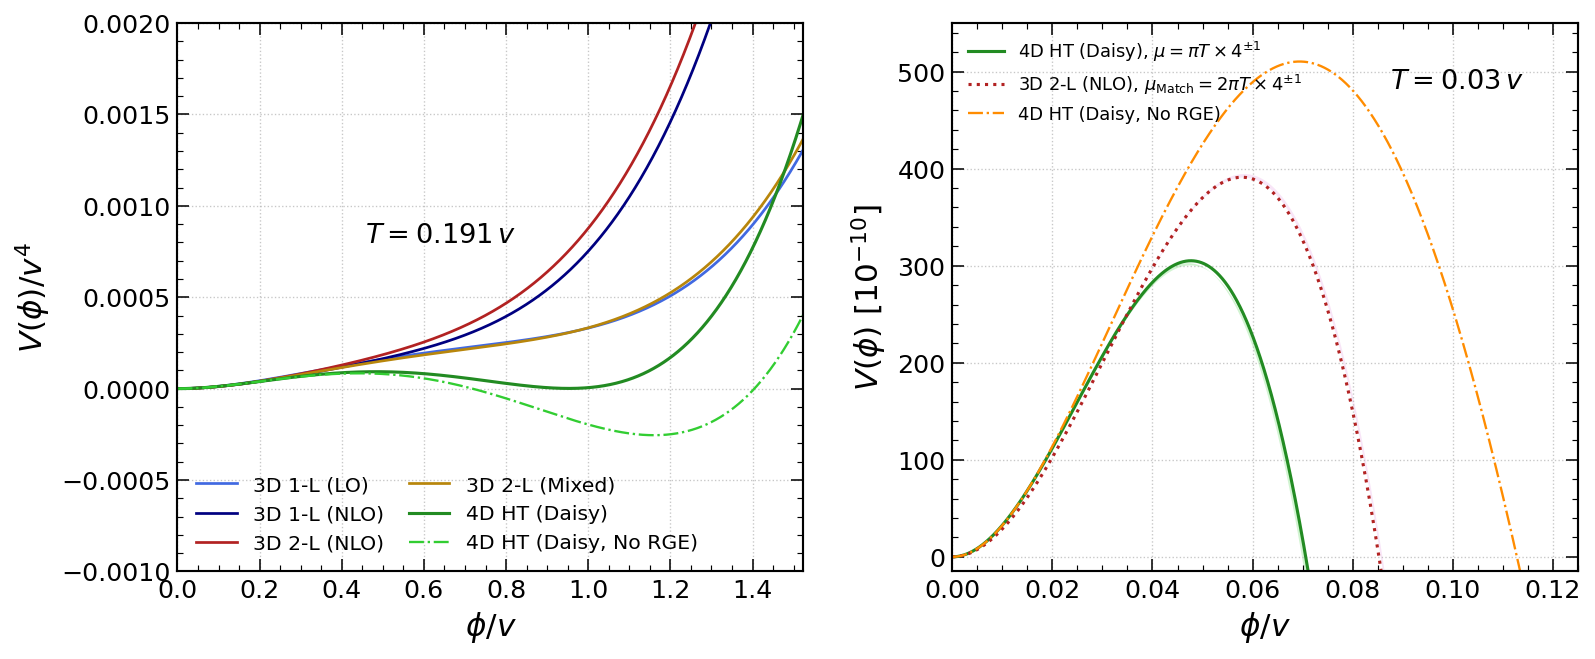

In [93]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from matplotlib.ticker import AutoMinorLocator

from custom_model import AbelianHiggsMSbarPaper
from model_3d import AbelianHiggsDR3D


# ============================================================
# Global plot style
# ============================================================
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 13,
    "axes.labelsize": 16,
    "axes.titlesize": 15,
    "legend.fontsize": 10.5,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "axes.linewidth": 1.1,
    "lines.linewidth": 1.6,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
})


# ============================================================
# Helpers: zero-T 4D VEV to define v
# ============================================================
def safe_log_arg(x, floor=1e-300):
    return np.maximum(np.abs(x), floor)


def safe_mass4_log_term(m2, mu2, const):
    return (m2**2) * (np.log(safe_log_arg(m2) / mu2) - const)


def Veff_zeroT(phi, model, mu):
    g2, lam, m2 = model.run_params(mu)
    mu2 = mu**2

    Vtree = -0.5 * m2 * phi**2 + 0.25 * lam * phi**4

    mH2 = 3.0 * lam * phi**2 - m2
    mG2 = 1.0 * lam * phi**2 - m2
    mA2 = g2 * phi**2

    termH = safe_mass4_log_term(mH2, mu2, 1.5)
    termG = safe_mass4_log_term(mG2, mu2, 1.5)
    termA = 3.0 * safe_mass4_log_term(mA2, mu2, 5.0 / 6.0)

    VCW = (termH + termG + termA) / (64.0 * np.pi**2)
    return Vtree + VCW


def find_vev(model, mu, phi_max=8.0, ngrid=4000):
    phis = np.linspace(1e-6, phi_max, ngrid)
    vals = np.array([Veff_zeroT(phi, model, mu) for phi in phis])

    i_min = np.argmin(vals)
    phi_guess = phis[i_min]

    if i_min == 0 or i_min == len(phis) - 1:
        phi_max = 20.0
        phis = np.linspace(1e-6, phi_max, ngrid)
        vals = np.array([Veff_zeroT(phi, model, mu) for phi in phis])
        i_min = np.argmin(vals)
        phi_guess = phis[i_min]

    left = phis[max(i_min - 1, 0)]
    right = phis[min(i_min + 1, len(phis) - 1)]

    if right - left < 1e-8:
        left = max(phi_guess * 0.8, 1e-8)
        right = phi_guess * 1.2 + 1e-8

    res = minimize_scalar(
        lambda x: Veff_zeroT(x, model, mu),
        bounds=(left, right),
        method="bounded",
    )
    return float(res.x)


# ============================================================
# Small wrappers to vary the renormalisation scale
# ============================================================
class HT4DVarMu(AbelianHiggsMSbarPaper):
    def __init__(self, *args, mu_factor=1.0, **kwargs):
        super().__init__(*args, **kwargs)
        self._mu_factor = float(mu_factor)

        def mu_eff_override(T):
            T = float(T)
            if T > 0.0:
                return max(self._mu_factor * np.pi * T, 1e-12)
            return max(self.mu0, 1e-12)

        self.mu_eff = mu_eff_override


class DR3DVarMuMatch(AbelianHiggsDR3D):
    def __init__(self, *args, mu_match_factor=1.0, **kwargs):
        super().__init__(*args, **kwargs)
        self._mu_match_factor = float(mu_match_factor)

    def mu_match(self, T):
        return max(self._mu_match_factor * 2.0 * np.pi * float(T), 1e-12)


# ============================================================
# Potential evaluators
# Shift by V(0,T) and divide by v^4 for display
# ============================================================
def V4_curve(model, phi_array, T, vnorm):
    phi_array = np.asarray(phi_array, dtype=float)
    X = phi_array[..., None]
    X0 = np.array([[0.0]], dtype=float)

    vals = np.asarray(model.Vtot(X, T, include_radiation=False), dtype=float)
    v0 = float(np.asarray(model.Vtot(X0, T, include_radiation=False), dtype=float).reshape(-1)[0])

    return (vals.reshape(phi_array.shape) - v0) / vnorm**4


def V3_curve(model, phi4_array, T, vnorm):
    phi4_array = np.asarray(phi4_array, dtype=float)

    vals = np.asarray(model.V4_equiv(phi4_array, T), dtype=float)
    v0 = float(np.asarray(model.V4_equiv(np.array([0.0]), T), dtype=float).reshape(-1)[0])

    return (vals.reshape(phi4_array.shape) - v0) / vnorm**4


# ============================================================
# User benchmark
# ============================================================
mu0 = 1.0
g0 = 0.6
g2_0 = g0**2
lam0 = 0.0
m20 = 0.0
Yphi = 1.0

# Base 4D model for defining v
model_4d_base = HT4DVarMu(
    g2_0=g2_0,
    lambda_0=lam0,
    m2_0=m20,
    mu0=mu0,
    use_running=True,
    use_paper_mu=False,
    mu_factor=1.0,
)

v = find_vev(model_4d_base, mu0, phi_max=8.0, ngrid=4000)
print(f"Using v = {v:.8f} (in units of mu0)")

# This reproduces the raw-temperature point that showed the FOPT clearly
T_left = 0.191 * v
T_right = 0.03 * v

# ============================================================
# Field grids
# Internal left grid is in raw phi, display axis is phi/v
# ============================================================
phi_left_max = 3.0
phi_left = np.linspace(0.0, phi_left_max, 4000)
phi_over_v_left = phi_left / v

phi_over_v_right = np.linspace(0.0, 0.125, 4000)
phi_right = phi_over_v_right * v


# ============================================================
# Build models
# ============================================================
ht_ref = HT4DVarMu(
    g2_0=g2_0,
    lambda_0=lam0,
    m2_0=m20,
    mu0=mu0,
    use_running=True,
    use_paper_mu=False,
    mu_factor=1.0,
)

ht_no_rge = HT4DVarMu(
    g2_0=g2_0,
    lambda_0=lam0,
    m2_0=m20,
    mu0=mu0,
    use_running=False,
    use_paper_mu=False,
    mu_factor=1.0,
)

ht_low = HT4DVarMu(
    g2_0=g2_0,
    lambda_0=lam0,
    m2_0=m20,
    mu0=mu0,
    use_running=True,
    use_paper_mu=False,
    mu_factor=0.25,
)

ht_high = HT4DVarMu(
    g2_0=g2_0,
    lambda_0=lam0,
    m2_0=m20,
    mu0=mu0,
    use_running=True,
    use_paper_mu=False,
    mu_factor=4.0,
)

dr_1l_lo = DR3DVarMuMatch(
    g1_0=g0, lam_0=lam0, msq_0=m20, mu0=mu0, Yphi=Yphi,
    scheme="3D-1L-LO", use_running=True, mu_match_factor=1.0
)

dr_1l_nlo = DR3DVarMuMatch(
    g1_0=g0, lam_0=lam0, msq_0=m20, mu0=mu0, Yphi=Yphi,
    scheme="3D-1L-NLO", use_running=True, mu_match_factor=1.0
)

dr_2l_nlo = DR3DVarMuMatch(
    g1_0=g0, lam_0=lam0, msq_0=m20, mu0=mu0, Yphi=Yphi,
    scheme="3D-2L-NLO", use_running=True, mu_match_factor=1.0
)

dr_2l_mixed = DR3DVarMuMatch(
    g1_0=g0, lam_0=lam0, msq_0=m20, mu0=mu0, Yphi=Yphi,
    scheme="3D-2L-MIXED", use_running=True, mu_match_factor=1.0
)

dr_2l_low = DR3DVarMuMatch(
    g1_0=g0, lam_0=lam0, msq_0=m20, mu0=mu0, Yphi=Yphi,
    scheme="3D-2L-NLO", use_running=True, mu_match_factor=0.25
)

dr_2l_high = DR3DVarMuMatch(
    g1_0=g0, lam_0=lam0, msq_0=m20, mu0=mu0, Yphi=Yphi,
    scheme="3D-2L-NLO", use_running=True, mu_match_factor=4.0
)


# ============================================================
# Evaluate curves
# ============================================================
# Left panel
V_1l_lo_L = V3_curve(dr_1l_lo, phi_left, T_left, v)
V_1l_nlo_L = V3_curve(dr_1l_nlo, phi_left, T_left, v)
V_2l_nlo_L = V3_curve(dr_2l_nlo, phi_left, T_left, v)
V_2l_mix_L = V3_curve(dr_2l_mixed, phi_left, T_left, v)
V_ht_ref_L = V4_curve(ht_ref, phi_left, T_left, v)
V_ht_no_rge_L = V4_curve(ht_no_rge, phi_left, T_left, v)

# Right panel
V_ht_ref_R = V4_curve(ht_ref, phi_right, T_right, v)
V_ht_no_rge_R = V4_curve(ht_no_rge, phi_right, T_right, v)
V_ht_low_R = V4_curve(ht_low, phi_right, T_right, v)
V_ht_high_R = V4_curve(ht_high, phi_right, T_right, v)

V_2l_ref_R = V3_curve(dr_2l_nlo, phi_right, T_right, v)


V_2l_low_R = V3_curve(dr_2l_low, phi_right, T_right, v)
V_2l_high_R = V3_curve(dr_2l_high, phi_right, T_right, v)

# Scale right panel like the paper
scale_right = 1e10
V_ht_ref_R *= scale_right
V_ht_no_rge_R *= scale_right
V_ht_low_R *= scale_right
V_ht_high_R *= scale_right
V_2l_ref_R *= scale_right
V_2l_low_R *= scale_right
V_2l_high_R *= scale_right


# ============================================================
# Helper for automatic y-limits
# ============================================================
def padded_limits(*arrays, frac=0.10):
    y = np.concatenate([np.ravel(a) for a in arrays])
    ymin = np.min(y)
    ymax = np.max(y)
    span = ymax - ymin
    if span <= 0:
        span = max(abs(ymax), 1.0)
    return ymin - frac * span, ymax + frac * span


# ============================================================
# Plot
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.9))

# Colors chosen to be clean and print-friendly
c_1l_lo = "royalblue"
c_1l_nlo = "navy"
c_2l_nlo = "firebrick"
c_2l_mix = "darkgoldenrod"
c_4d_ref = "forestgreen"
c_4d_norge = "limegreen"
c_band4d = "limegreen"
c_band3d = "orchid"

# ---------------- left ----------------
ax = axes[0]
ax.plot(phi_over_v_left, V_1l_lo_L, color=c_1l_lo, lw=1.4, label="3D 1-L (LO)")
ax.plot(phi_over_v_left, V_1l_nlo_L, color=c_1l_nlo, lw=1.4, label="3D 1-L (NLO)")
ax.plot(phi_over_v_left, V_2l_nlo_L, color=c_2l_nlo, lw=1.4, label="3D 2-L (NLO)")
ax.plot(phi_over_v_left, V_2l_mix_L, color=c_2l_mix, lw=1.4, label="3D 2-L (Mixed)")
ax.plot(phi_over_v_left, V_ht_ref_L, color=c_4d_ref, lw=1.6, label="4D HT (Daisy)")
ax.plot(phi_over_v_left, V_ht_no_rge_L, color=c_4d_norge, lw=1.2, ls="-.", label="4D HT (Daisy, No RGE)")

ax.set_xlim(phi_over_v_left.min(), phi_over_v_left.max())
ax.set_ylim(-0.001, 0.002)
ax.set_xlabel(r"$\phi / v$")
ax.set_ylabel(r"$V(\phi) / v^4$")
ax.text(0.3, 0.6, rf"$T = {T_left/v:.3f}\,v$", transform=ax.transAxes, fontsize=14)

ax.grid(True, ls=":", lw=0.7, alpha=0.7)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.legend(frameon=False, ncol=2, loc="best", columnspacing=1.2, handlelength=2.0)

# ---------------- right ----------------
ax = axes[1]

band_ht_lo = np.minimum(V_ht_low_R, V_ht_high_R)
band_ht_hi = np.maximum(V_ht_low_R, V_ht_high_R)
ax.fill_between(
    phi_over_v_right, band_ht_lo, band_ht_hi,
    color=c_band4d, alpha=0.22, linewidth=0.0
)
ax.plot(
    phi_over_v_right, V_ht_ref_R,
    color=c_4d_ref, lw=1.6,
    label=r"4D HT (Daisy), $\mu=\pi T\times 4^{\pm1}$"
)

band_3d_lo = np.minimum(V_2l_low_R, V_2l_high_R)
band_3d_hi = np.maximum(V_2l_low_R, V_2l_high_R)
ax.fill_between(
    phi_over_v_right, band_3d_lo, band_3d_hi,
    color=c_band3d, alpha=0.18, linewidth=0.0
)
ax.plot(
    phi_over_v_right, V_2l_ref_R,
    color=c_2l_nlo, lw=1.6, ls=":",
    label=r"3D 2-L (NLO), $\mu_{\mathrm{Match}}=2\pi T\times 4^{\pm1}$"
)

ax.plot(
    phi_over_v_right, V_ht_no_rge_R,
    color="darkorange", lw=1.2, ls="-.",
    label="4D HT (Daisy, No RGE)"
)

ax.set_xlim(0.0, 0.125)
ax.set_ylim(-15, 550.0)
ax.set_xlabel(r"$\phi / v$")
ax.set_ylabel(r"$V(\phi)\ [10^{-10}]$")
ax.text(0.7, 0.88, rf"$T = {T_right/v:.2f}\,v$", transform=ax.transAxes, fontsize=14)

ax.grid(True, ls=":", lw=0.7, alpha=0.7)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.legend(frameon=False, loc="best", fontsize=9.2, handlelength=2.0)

plt.tight_layout()
plt.savefig("effective_potential_comparison_paper_style.png", bbox_inches="tight")
plt.show()

In [6]:

# Add ELENA/src to the Python path for imports (as suggested by the repo)
import sys, os
sys.path.append(os.path.abspath('src'))

In [11]:
import numpy as np
import temperatures as temp

def find_extrema_fast(
    V,
    dV_unused,
    T,
    Phimax=150,
    step=1,
    *,
    max_expand=2,          # 🔴 key: do NOT let ELENA expand too much
    Phimax_cap=1000,       # 🔴 hard cap
    min_phi_cut=1e-6,      # 🔴 ignore tiny junk extrema
):
    T = float(T)
    if T <= 0.0:
        return [], [], []

    Phimax = float(Phimax)
    step   = float(step)

    # mimic ELENA behaviour: exclude phi=0
    phi = np.arange(step, Phimax + step, step, dtype=float)
    v = np.asarray(V(phi.reshape(-1, 1), T), dtype=float).reshape(-1)

    expand_counter = 0
    argmaxV = np.argmax(v)

    # --------------------------------------------------
    # Controlled expansion ONLY if maximum is at boundary
    # --------------------------------------------------
    while (argmaxV + 1) != len(v):
        if np.isnan(v[argmaxV]):
            return [], [], []

        expand_counter += 1
        if expand_counter > max_expand or Phimax >= Phimax_cap:
            break

        Phimax *= 2.0
        Phimax = min(Phimax, Phimax_cap)

        phi = np.arange(step, Phimax + step, step, dtype=float)
        v = np.asarray(V(phi.reshape(-1, 1), T), dtype=float).reshape(-1)
        argmaxV = np.argmax(v)

    # sanity check
    if len(v) < 5 or not np.all(np.isfinite(v)):
        return [], [], []

    # --------------------------------------------------
    # Derivative from uniform grid
    # --------------------------------------------------
    dv = np.gradient(v, phi)
    signs = np.sign(dv).astype(int)

    sign_changes = np.diff(signs)
    idxs = np.nonzero(np.abs(sign_changes) == 2)[0]

    loc, val, kind = [], [], []

    for idx in idxs:
        this_kind = "max" if sign_changes[idx] < 0 else "min"

        # linear dv=0 interpolation
        phi_pair = phi[idx:idx+2]
        dv_pair = dv[idx:idx+2]
        v_pair  = v[idx:idx+2]

        if this_kind == "max":
            xz = np.interp(0.0, dv_pair[::-1], phi_pair[::-1])
        else:
            xz = np.interp(0.0, dv_pair, phi_pair)

        if xz < min_phi_cut:
            continue  # 🔴 ignore tiny unphysical extrema

        vz = np.interp(xz, phi_pair, v_pair)

        kind.append(this_kind)
        loc.append(float(xz))
        val.append(float(vz))

    if not kind:
        return [], [], []

    # --------------------------------------------------
    # sort & truncate like ELENA, but HARD LIMIT LENGTH
    # --------------------------------------------------
    order = np.argsort(loc)
    kind = list(np.array(kind)[order])
    loc  = list(np.array(loc)[order])
    val  = list(np.array(val)[order])

    # 🔴 HARD LIMIT: only keep first few extrema
    MAX_KEEP = 4
    kind = kind[:MAX_KEEP]
    loc  = loc[:MAX_KEEP]
    val  = val[:MAX_KEEP]

    # truncate past global minimum (ELENA logic)
    gmin = int(np.argmin(val))
    kind = kind[:gmin+1]
    loc  = loc[:gmin+1]
    val  = val[:gmin+1]

    return kind, loc, val


# === PATCH INTO ELENA ===
temp.find_extrema = find_extrema_fast

In [16]:
import numpy as np

from temperatures import find_T_min, find_T_max, refine_Tmin
from model_3d import AbelianHiggsDR3D


# ============================================================
# Model parameters (paper point)
# ============================================================
g0   = 0.6
lam0 = 0.0
m20  = 0.0
mu0  = 1.0
Yphi = 1.0

units = "GeV"


# ============================================================
# Numerical scan scales (tuned for this model)
# ============================================================
tmax = 1.2              # safely above expected T_max ~ 0.3–0.4
T_precision = 1e-2

Phimax   = 3.5          # φ ~ O(μ/g)
step_phi = 0.02

T_EPS = 1e-6            # protect 3D EFT from T=0 probes


# ============================================================
# DR schemes to scan
# ============================================================
schemes = [
    "3D-1L-LO",
    "3D-1L-NLO",
    "3D-2L-NLO",
    "3D-2L-MIXED",
]


# ============================================================
# Loop over schemes
# ============================================================
print("\n===== ELENA spinodal scan for 3D DR schemes =====\n")

for scheme in schemes:

    print(f"--- {scheme} ---")

    # build 3D DR model
    dp = AbelianHiggsDR3D(
        g1_0=g0,
        lam_0=lam0,
        msq_0=m20,
        mu0=mu0,
        Yphi=Yphi,
        scheme=scheme,
        use_running=True,
    )

    # --------------------------------------------------------
    # ELENA-compatible V and dV wrappers
    # --------------------------------------------------------
    def V(phi, T):
        phi = np.atleast_1d(phi).astype(float)
        T_use = max(float(T), T_EPS)
        return np.asarray(dp.V4_equiv(phi, T_use), dtype=float)

    def dV(phi, T):
        phi = np.atleast_1d(phi).astype(float)
        T_use = max(float(T), T_EPS)
        h = 1e-4 * np.maximum(np.abs(phi), 1.0)
        return (
            dp.V4_equiv(phi + h, T_use)
            - dp.V4_equiv(phi - h, T_use)
        ) / (2.0 * h)

    # --------------------------------------------------------
    # ELENA-style temperature scan
    # --------------------------------------------------------
    T_max, vevs_max, max_min_vals, false_min_tmax = find_T_max(
        V,
        dV,
        precision=T_precision,
        Phimax=Phimax,
        step_phi=step_phi,
        tmax=tmax,
    )

    T_min, vevs_min, false_min_tmin = find_T_min(
        V,
        dV,
        tmax=T_max,
        precision=T_precision,
        Phimax=Phimax,
        step_phi=step_phi,
        max_min_vals=max_min_vals,
    )

    # --------------------------------------------------------
    # maxvev (exact ELENA logic)
    # --------------------------------------------------------
    if T_max is not None and T_min is not None:
        maxvev = np.max(np.concatenate((vevs_max, vevs_min)))
    elif T_max is not None:
        maxvev = np.max(vevs_max)
    elif T_min is not None:
        maxvev = np.max(vevs_min)
    else:
        maxvev = None

    # --------------------------------------------------------
    # refine Tmin
    # --------------------------------------------------------
    T_min = (
        refine_Tmin(T_min, V, dV, maxvev, log_10_precision=6)
        if T_min is not None else None
    )

    # --------------------------------------------------------
    # Print results
    # --------------------------------------------------------
    print(f"T_max = {T_max:.6e} {units}" if T_max is not None else "T_max = None")
    print(f"T_min = {T_min:.6e} {units}" if T_min is not None else "T_min < IR cutoff")

    if vevs_max is not None:
        print("vevs_max (sample):", vevs_max[:5])
    if vevs_min is not None:
        print("vevs_min (sample):", vevs_min[:5])

    print()



===== ELENA spinodal scan for 3D DR schemes =====

--- 3D-1L-LO ---
T_max = 3.105600e-01 GeV
T_min = 1.608400e-01 GeV
vevs_max (sample): [2.33106499 2.20002645 2.18676452]
vevs_min (sample): [13.2920105]

--- 3D-1L-NLO ---
T_max = 2.109600e-01 GeV
T_min = 1.024144e-01 GeV
vevs_max (sample): [1.42466207 1.36002751 1.34949561]
vevs_min (sample): [13.04304684]

--- 3D-2L-NLO ---
T_max = 1.968960e-01 GeV
T_min = 1.024947e-01 GeV
vevs_max (sample): [1.43089299 1.3634333  1.36349972 1.36215061]
vevs_min (sample): [11.67967912]

--- 3D-2L-MIXED ---
T_max = 3.080400e-01 GeV
T_min = 1.610180e-01 GeV
vevs_max (sample): [2.26794453 2.16572864 2.15368206]
vevs_min (sample): [12.02120566]



In [18]:
import numpy as np
from temperatures import find_T_min, find_T_max, refine_Tmin
from model_3d import AbelianHiggsDR3D

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------
g0   = 0.6
lam0 = 0.0
m20  = 0.0
mu0  = 1.0
Yphi = 1.0
units = "GeV"

T_EPS = 1e-6

tmax        = 1.2
T_precision = 1e-2
Phimax      = 3.5
step_phi    = 0.02

schemes = [
    "3D-1L-LO",
    "3D-1L-NLO",
    "3D-2L-NLO",
    "3D-2L-MIXED",
]

# ------------------------------------------------------------
# Storage dictionaries (THIS FIXES THE NameError)
# ------------------------------------------------------------
dr_models  = {}
T_max_dict = {}
T_min_dict = {}

print("\n===== ELENA spinodal scan =====\n")

for scheme in schemes:
    print(f"--- {scheme} ---")

    dp = AbelianHiggsDR3D(
        g1_0=g0,
        lam_0=lam0,
        msq_0=m20,
        mu0=mu0,
        Yphi=Yphi,
        scheme=scheme,
        use_running=True,
    )

    dr_models[scheme] = dp

    def V(phi, T):
        phi = np.atleast_1d(phi).astype(float)
        return np.asarray(dp.V4_equiv(phi, max(T, T_EPS)), dtype=float)

    def dV(phi, T):
        phi = np.atleast_1d(phi).astype(float)
        h = 1e-4 * np.maximum(np.abs(phi), 1.0)
        T = max(T, T_EPS)
        return (
            dp.V4_equiv(phi + h, T)
            - dp.V4_equiv(phi - h, T)
        ) / (2.0 * h)

    T_max, vevs_max, max_min_vals, _ = find_T_max(
        V, dV,
        precision=T_precision,
        Phimax=Phimax,
        step_phi=step_phi,
        tmax=tmax,
    )

    T_min, vevs_min, _ = find_T_min(
        V, dV,
        tmax=T_max,
        precision=T_precision,
        Phimax=Phimax,
        step_phi=step_phi,
        max_min_vals=max_min_vals,
    )

    if T_max is not None and T_min is not None:
        maxvev = np.max(np.concatenate((vevs_max, vevs_min)))
    elif T_max is not None:
        maxvev = np.max(vevs_max)
    elif T_min is not None:
        maxvev = np.max(vevs_min)
    else:
        maxvev = None

    if T_min is not None:
        T_min = refine_Tmin(T_min, V, dV, maxvev, log_10_precision=6)

    # ✅ SAVE RESULTS
    T_max_dict[scheme] = T_max
    T_min_dict[scheme] = T_min

    print(f"T_max = {T_max:.4e}, T_min = {T_min if T_min else '< IR cutoff>'}")



===== ELENA spinodal scan =====

--- 3D-1L-LO ---
T_max = 3.1056e-01, T_min = 0.16084004085658132
--- 3D-1L-NLO ---
T_max = 2.1096e-01, T_min = 0.10241440121062126
--- 3D-2L-NLO ---
T_max = 1.9690e-01, T_min = 0.10249468638188461
--- 3D-2L-MIXED ---
T_max = 3.0804e-01, T_min = 0.16101803791089125


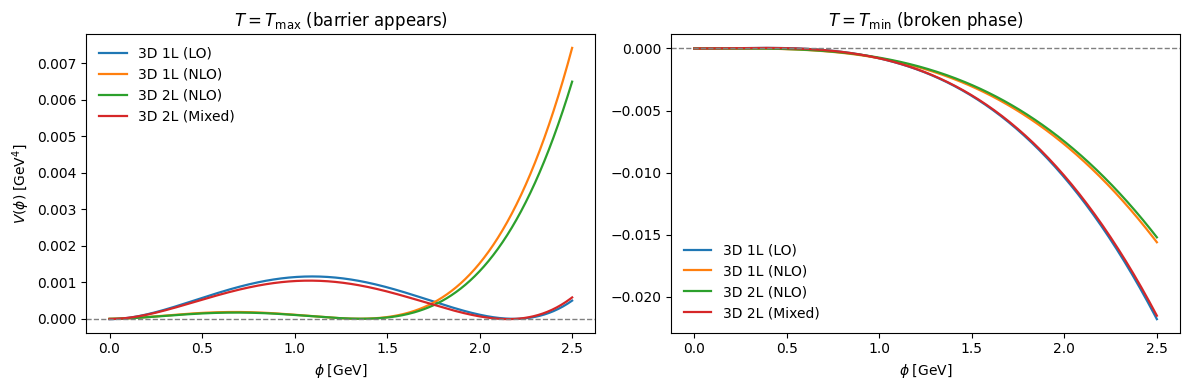

In [22]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["text.usetex"] = False

phi = np.linspace(0.0, 2.5, 300)
units = "GeV"
T_IR_PLOT = 1e-3

labels = {
    "3D-1L-LO":    "3D 1L (LO)",
    "3D-1L-NLO":   "3D 1L (NLO)",
    "3D-2L-NLO":   "3D 2L (NLO)",
    "3D-2L-MIXED": "3D 2L (Mixed)",
}

colors = {
    "3D-1L-LO":    "tab:blue",
    "3D-1L-NLO":   "tab:orange",
    "3D-2L-NLO":   "tab:green",
    "3D-2L-MIXED": "tab:red",
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ------------------------------------------------------------
# T = T_max
# ------------------------------------------------------------
for scheme in schemes:
    Tm = T_max_dict.get(scheme)
    if Tm is None:
        continue
    dp = dr_models[scheme]
    axes[0].plot(
        phi,
        dp.V4_equiv(phi, Tm),
        label=labels[scheme],
        color=colors[scheme],
        lw=1.6,
    )

axes[0].set_title(r"$T = T_{\max}$ (barrier appears)")
axes[0].set_xlabel(r"$\phi\;[\mathrm{GeV}]$")
axes[0].set_ylabel(r"$V(\phi)\;[\mathrm{GeV}^4]$")
axes[0].axhline(0.0, color="grey", ls="--", lw=1)
axes[0].legend(frameon=False)

# ------------------------------------------------------------
# T = T_min
# ------------------------------------------------------------
for scheme in schemes:
    dp = dr_models[scheme]
    Tm = T_min_dict.get(scheme)
    T_plot = Tm if Tm is not None else T_IR_PLOT
    axes[1].plot(
        phi,
        dp.V4_equiv(phi, T_plot),
        label=labels[scheme],
        color=colors[scheme],
        lw=1.6,
    )

axes[1].set_title(r"$T = T_{\min}$ (broken phase)")
axes[1].set_xlabel(r"$\phi\;[\mathrm{GeV}]$")
axes[1].axhline(0.0, color="grey", ls="--", lw=1)
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()